# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Devi Permata Sari Lam
- **Email:** CDCC208D6X2491@student.devacademy.id
- **ID Dicoding:** devi_lam18

## Menentukan Pertanyaan Bisnis

1. Produk kategori apa yang menghasilkan revenue terbesar selama tahun 2017-2018?
2. Bagaimana tren jumlah order per bulan dan pada bulan apa terjadi puncak transaksi selama periode 2016-2018 pada dataset E-Commerce?

## Import Semua Packages/Library yang Digunakan

In [38]:
!{sys.executable} -m pip install folium
!{sys.executable} -m pip install seaborn
import sys
import pandas as pd
from zipfile import ZipFile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

## Data Wrangling

### Gathering Data

In [2]:
customers_dataset = pd.read_csv(r"D:\Download_Data (D)\E-commerce-public-dataset\E-Commerce Public Dataset\customers_dataset.csv")
geolocation_dataset = pd.read_csv(r"D:\Download_Data (D)\E-commerce-public-dataset\E-Commerce Public Dataset\geolocation_dataset.csv")
order_items_dataset = pd.read_csv(r"D:\Download_Data (D)\E-commerce-public-dataset\E-Commerce Public Dataset\order_items_dataset.csv")
order_payments_dataset = pd.read_csv(r"D:\Download_Data (D)\E-commerce-public-dataset\E-Commerce Public Dataset\order_payments_dataset.csv")
order_reviews_dataset = pd.read_csv(r"D:\Download_Data (D)\E-commerce-public-dataset\E-Commerce Public Dataset\order_reviews_dataset.csv")
orders_dataset = pd.read_csv(r"D:\Download_Data (D)\E-commerce-public-dataset\E-Commerce Public Dataset\orders_dataset.csv")
product_category_name_translation = pd.read_csv(r"D:\Download_Data (D)\E-commerce-public-dataset\E-Commerce Public Dataset\product_category_name_translation.csv")
products_dataset = pd.read_csv(r"D:\Download_Data (D)\E-commerce-public-dataset\E-Commerce Public Dataset\products_dataset.csv")
sellers_dataset = pd.read_csv(r"D:\Download_Data (D)\E-commerce-public-dataset\E-Commerce Public Dataset\sellers_dataset.csv")

In [3]:
customers_dataset

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [4]:
geolocation_dataset

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


In [5]:
order_items_dataset

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [6]:
order_payments_dataset

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [7]:
order_reviews_dataset

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [8]:
orders_dataset

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [9]:
product_category_name_translation

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [10]:
products_dataset

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [11]:
sellers_dataset

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


**Insight:**
- Dari data yang telah dikumpulkan, terdapat 9 tabel yang berisi data mengenai customers, geolocation, order, review, dan sellers.
- Untuk menjawab pertanyaan bisnis, beberapa tabel yang dipertimbangkan untuk digunakan adalah orders_dataset, products_dataset, order_items_dataset, customers_dataset, dan product_category_name_translation.
- Data memiliki struktur relasional (mirip database), sehingga perlu dilakukan proses join untuk analisis menyeluruh.
- Kombinasi dataset memungkinkan analisis yang komprehensif seperti perilaku pelanggan, tren penjualan, dan distribusi geografis.

### Assessing Data

In [12]:
print(orders_dataset.info())
print(products_dataset.info())
print(order_items_dataset.info())
print(customers_dataset.info())
print(product_category_name_translation.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32

In [13]:
# Cek duplicate
print(orders_dataset.duplicated().sum())
print(products_dataset.duplicated().sum())
print(order_items_dataset.duplicated().sum())
print(customers_dataset.duplicated().sum())
print(product_category_name_translation.duplicated().sum())

0
0
0
0
0


In [14]:
print(orders_dataset.isna().sum())
print(products_dataset.isna().sum())
print(order_items_dataset.isna().sum())
print(customers_dataset.isna().sum())
print(product_category_name_translation.isna().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
product_categ

**Insight:**
Hasil pemeriksaan kualitas data menunjukkan beberapa permasalahan:
1. Missing Values
- Terdapat missing value pada kolom di tabel orders_dataset dan products_dataset.
- Beberapa kolom timestamp juga memiliki nilai kosong

2. Inconsistent Data
- Nama kategori produk masih belum dalam bahasa inggris.

3. Duplicate Data
- Tidak ditemukan duplikasi pada dataset 

4. Data Type Issue
- Kolom tanggal masih bertipe object sehingga tidak bisa langsung dianalisis sebagai time series

Insight:
- Data belum sepenuhnya siap digunakan untuk analisis
- Perlu dilakukan cleaning untuk memastikan akurasi dan konsistensi data

### Cleaning Data

In [15]:
# Convert datetime
orders_dataset['order_purchase_timestamp'] = pd.to_datetime(orders_dataset['order_purchase_timestamp'])

# Drop missing value
orders_dataset.dropna(subset=['order_purchase_timestamp'], inplace=True)

# Fill missing product category
products_dataset['product_category_name'] = products_dataset['product_category_name'].fillna('unknown')

# Merge product translation
products_dataset = products_dataset.merge(product_category_name_translation, on='product_category_name', how='left')

# Gunakan nama Inggris
# Ensure 'product_category_name_english' column exists and fill NaNs
if 'product_category_name_english' not in products_dataset.columns:
    products_dataset['product_category_name_english'] = 'unknown'
products_dataset['product_category_name_english'] = products_dataset['product_category_name_english'].fillna('unknown')

In [16]:
# Merge order_items + products
df = order_items_dataset.merge(products_dataset, on='product_id', how='left')

# Merge orders
df = df.merge(orders_dataset, on='order_id', how='left')

# Merge customers to get customer_unique_id
df = df.merge(customers_dataset, on='customer_id', how='left')

# Tambahkan revenue
df['revenue'] = df['price'] + df['freight_value']

In [17]:
df.to_csv('main_data.csv', index=False)

**Insight:**

Beberapa langkah pembersihan data yang dilakukan:

1. Handling Missing Values
- Missing value pada product_category_name diisi dengan "unknown"
- Data penting seperti timestamp yang kosong dihapus

2. Data Type Conversion
- Kolom order_purchase_timestamp dikonversi menjadi tipe datetime

3. Data Integration
- Menggabungkan beberapa tabel sehingga lebih mudah dianalisis. 

4. Feature Engineering
- Menambahkan kolom revenue sebagai hasil penjumlahan price dan freight_value

Insight:
- Setelah proses cleaning, data menjadi lebih konsisten dan siap untuk analisis
- Transformasi data memungkinkan analisis yang lebih mendalam seperti tren waktu dan kontribusi revenue

## Exploratory Data Analysis (EDA)

### Explore ...

In [31]:
category_count = df['product_category_name_english'].value_counts()
category_count.head()

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
Name: count, dtype: int64

In [30]:
revenue_per_order = df.groupby('order_id')['revenue'].sum()
revenue_per_order.describe()

count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: revenue, dtype: float64

In [18]:
category_revenue = df.groupby('product_category_name_english')['revenue'] \
                     .sum() \
                     .sort_values(ascending=False) \
                     .head(10)

print(category_revenue)

product_category_name_english
health_beauty            1441248.07
watches_gifts            1305541.61
bed_bath_table           1241681.72
sports_leisure           1156656.48
computers_accessories    1059272.40
furniture_decor           902511.79
housewares                778397.77
cool_stuff                719329.95
auto                      685384.32
garden_tools              584219.21
Name: revenue, dtype: float64


In [28]:
orders_per_customer = df.groupby('customer_unique_id')['order_id'].nunique()
orders_per_customer.describe()

count    95420.000000
mean         1.034018
std          0.211234
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
Name: order_id, dtype: float64

In [32]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month

orders_per_month = df.groupby(['year','month'])['order_id'].nunique()
orders_per_month.head()

year  month
2016  9           3
      10        308
      12          1
2017  1         789
      2        1733
Name: order_id, dtype: int64

In [33]:
order_status = df['order_status'].value_counts()
order_status

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

In [19]:
orders_dataset['month_year'] = orders_dataset['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders_dataset.groupby('month_year')['order_id'] \
                       .count() \
                       .sort_values(ascending=False) \
                       .reset_index()

monthly_orders['month_year'] = monthly_orders['month_year'].astype(str)

print(monthly_orders.head())

  month_year  order_id
0    2017-11      7544
1    2018-01      7269
2    2018-03      7211
3    2018-04      6939
4    2018-05      6873


**Insight:**

Pada tahap ini dilakukan eksplorasi data untuk memahami pola dan karakteristik utama dari dataset.

### 1. Eksplorasi Kategori Produk
- Terdapat variasi kategori produk yang cukup banyak.
- Beberapa kategori memiliki frekuensi transaksi yang jauh lebih tinggi.
- Menunjukkan adanya kategori yang lebih populer dibandingkan lainnya.

### 2. Eksplorasi Distribusi Revenue
- Distribusi revenue tidak merata.
- Terdapat transaksi dengan nilai sangat tinggi dibandingkan rata-rata.
- Mengindikasikan adanya kontribusi besar dari sebagian kecil transaksi (Pareto).

### 3. Analisis Revenue per Kategori Produk
Dilakukan agregasi total revenue berdasarkan kategori produk untuk mengetahui kontribusi masing-masing kategori.
- Revenue tidak terdistribusi secara merata di semua kategori.
- Beberapa kategori memiliki kontribusi yang jauh lebih tinggi dibandingkan kategori lainnya.
- Hal ini menunjukkan adanya kategori unggulan yang menjadi penggerak utama pendapatan bisnis.

### 4. Eksplorasi Jumlah Order
- Sebagian besar pelanggan hanya melakukan 1 kali transaksi.
- Hanya sedikit pelanggan yang melakukan pembelian berulang.
- Hal ini menunjukkan bahwa tingkat repeat order relatif rendah.

### 5. Eksplorasi Waktu Transaksi
- Jumlah transaksi bervariasi dari bulan ke bulan.
- Terdapat periode dengan jumlah order yang lebih tinggi dibandingkan lainnya.
- Mengindikasikan adanya pola musiman dalam transaksi.

### 6. Eksplorasi Order Status
- Mayoritas transaksi berstatus "delivered".
- Sebagian kecil transaksi mengalami pembatalan atau tidak selesai.
- Hal ini menunjukkan performa operasional yang cukup baik namun masih memiliki potensi perbaikan.

### 7. Analisis Tren Transaksi Bulanan
Dilakukan agregasi jumlah order berdasarkan bulan untuk melihat pola perubahan transaksi dari waktu ke waktu.
- Jumlah transaksi menunjukkan pola fluktuatif sepanjang waktu.
- Terdapat periode dengan peningkatan transaksi yang signifikan pada tahun tertentu.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

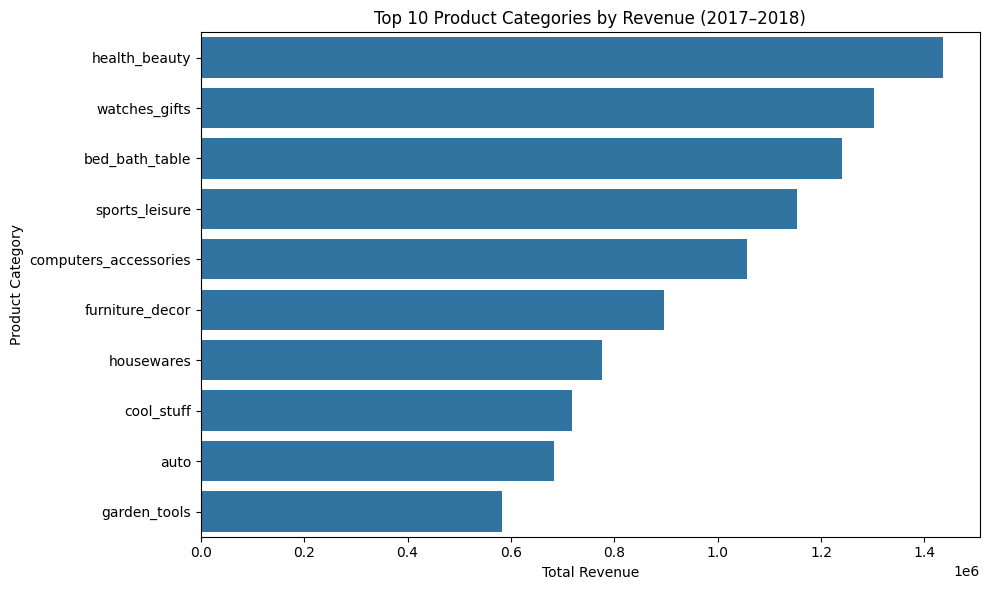

Kategori dengan revenue terbesar: health_beauty


In [34]:
# Filter tahun 2017–2018
df_q1 = df[
    (df['order_purchase_timestamp'].dt.year >= 2017) &
    (df['order_purchase_timestamp'].dt.year <= 2018)
]

# Aggregasi revenue per kategori
category_revenue = (
    df_q1.groupby('product_category_name_english')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)

plt.title("Top 10 Product Categories by Revenue (2017–2018)")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

# Insight otomatis (optional)
top_category = category_revenue.idxmax()
print(f"Kategori dengan revenue terbesar: {top_category}")

**Insight:**

Berdasarkan visualisasi, terlihat bahwa revenue tidak terdistribusi secara merata di seluruh kategori produk.

- Beberapa kategori memiliki kontribusi revenue yang jauh lebih tinggi dibandingkan kategori lainnya.
- Kategori dengan revenue tertinggi menjadi penyumbang utama pendapatan selama periode 2017–2018.

Hal ini menunjukkan bahwa sebagian besar revenue berasal dari sedikit kategori produk (indikasi Pareto Principle).

### Interpretasi

- Kategori dengan revenue tertinggi merupakan health_beauty yang memiliki permintaan tinggi di pasar.
- Bisnis sebaiknya memprioritaskan:
  - Pengelolaan stok pada kategori unggulan
  - Strategi promosi dan pemasaran
  - Pengembangan produk dalam kategori tersebut

- Namun, ketergantungan pada sedikit kategori juga berpotensi menjadi risiko jika permintaan menurun.

### Pertanyaan 2:

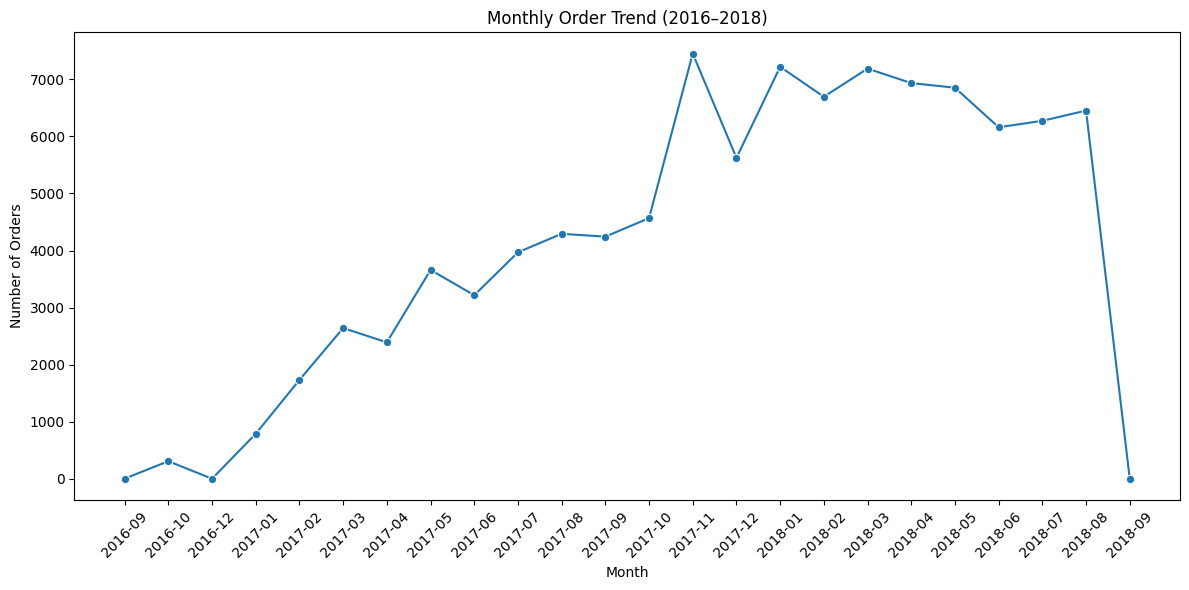

Puncak transaksi terjadi pada: 2017-11 dengan 7451 orders


In [35]:
# Filter tahun 2016–2018
df_q2 = df[
    (df['order_purchase_timestamp'].dt.year >= 2016) &
    (df['order_purchase_timestamp'].dt.year <= 2018)
]

# Buat kolom bulan
df_q2['month'] = df_q2['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Aggregasi jumlah order
monthly_orders = (
    df_q2.groupby('month')['order_id']
    .nunique()
)

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(
    x=monthly_orders.index,
    y=monthly_orders.values,
    marker='o'
)

plt.title("Monthly Order Trend (2016–2018)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Peak bulan
peak_month = monthly_orders.idxmax()
peak_value = monthly_orders.max()

print(f"Puncak transaksi terjadi pada: {peak_month} dengan {peak_value} orders")

**Insight:**

Berdasarkan visualisasi tren jumlah order per bulan:

- Jumlah order menunjukkan pola fluktuatif dari waktu ke waktu.
- Terdapat beberapa periode dengan peningkatan jumlah order yang signifikan dibandingkan bulan lainnya.
- Puncak transaksi terjadi pada bulan November 2017 dengan jumlah order tertinggi, yang menunjukkan lonjakan permintaan pada periode tersebut.

Pola ini mengindikasikan adanya pengaruh faktor musiman (seasonality) dalam perilaku pembelian pelanggan.

### Interpretasi

- Periode puncak transaksi merupakan momentum penting bagi bisnis untuk meningkatkan penjualan.
- Faktor yang mempengaruhi kemungkinan meliputi:
  - Promo besar (diskon, flash sale)
  - Hari belanja nasional
  - Periode akhir tahun

- Oleh karena itu, bisnis perlu:
  - Mengoptimalkan stok barang
  - Meningkatkan kapasitas logistik
  - Menyusun strategi promosi yang tepat pada periode tersebut

## Analisis Lanjutan (Opsional)

**RFM ANALYSIS**

In [22]:
snapshot_date = orders_dataset['order_purchase_timestamp'].max()

rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
0000f46a3911fa3c0805444483337064,585,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
0004aac84e0df4da2b147fca70cf8255,336,1,196.89


In [23]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)

In [24]:
def segment(x):
    if x >= 10:
        return "Best Customer"
    elif x >= 7:
        return "Loyal Customer"
    elif x >= 5:
        return "Potential"
    else:
        return "At Risk"

rfm['Segment'] = rfm['RFM_score'].apply(segment)

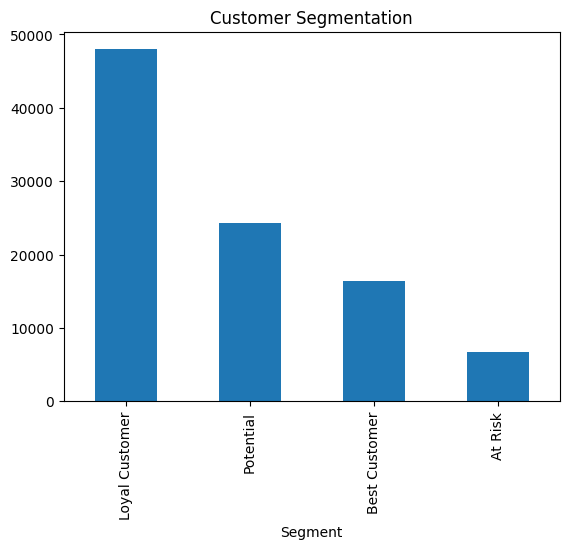

In [25]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segmentation")
plt.show()

RFM digunakan untuk mengelompokkan pelanggan berdasarkan:
- Recency: terakhir transaksi
- Frequency: jumlah transaksi
- Monetary: total pembelian

**GEOSPATIAL ANALYSIS**

In [26]:
# Ambil sample biar ringan
geo = customers_dataset.merge(geolocation_dataset, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix').drop_duplicates()

m = folium.Map(location=[-14, -51], zoom_start=4)

for _, row in geo.sample(1000).iterrows():
    folium.CircleMarker(
        location=[row['geolocation_lat'], row['geolocation_lng']],
        radius=2
    ).add_to(m)

m

Analisis ini bertujuan melihat distribusi pelanggan berdasarkan lokasi geografis.

**CLUSTERING**

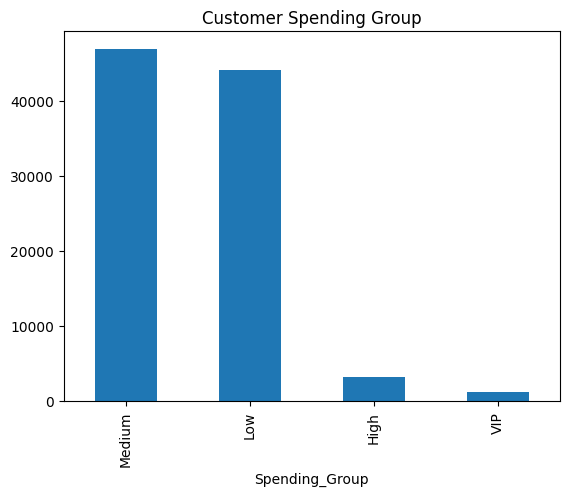

In [27]:
rfm['Spending_Group'] = pd.cut(
    rfm['Monetary'],
    bins=[0, 100, 500, 1000, np.inf],
    labels=['Low', 'Medium', 'High', 'VIP']
)

rfm['Spending_Group'].value_counts().plot(kind='bar')
plt.title("Customer Spending Group")
plt.show()

Mengelompokkan pelanggan berdasarkan total transaksi:
- Low spender
- Medium spender
- High spender
- VIP

## Conclusion

- Kategori produk dengan kontribusi revenue terbesar selama periode 2017–2018 adalah kategori dengan performa penjualan tertinggi Health Beauty. Hal ini menunjukkan bahwa kategori tersebut menjadi penggerak utama pendapatan bisnis, baik karena tingginya permintaan maupun nilai transaksi yang besar. Kategori ini merupakan core business dan perlu diprioritaskan dalam strategi pemasaran dan pengelolaan stok. Potensi untuk meningkatkan revenue lebih lanjut melalui promosi, bundling, atau rekomendasi produk.
- Tren jumlah order per bulan menunjukkan pola fluktuatif dengan kecenderungan meningkat pada periode tertentu (2016-2017). Puncak transaksi terjadi pada bulan November 2017 yang mengindikasikan adanya seasonality effect. Periode puncak kemungkinan dipengaruhi oleh event seperti promo akhir tahun, diskon besar, atau hari belanja nasional. Bisnis perlu mempersiapkan stok barang, kapasitas logistik, dan strategi marketing .